In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import warnings
warnings.filterwarnings('ignore')

In [2]:
# =============================================================================
# 2. Generate Dummy Data (Sensor + RUL)
# =============================================================================
np.random.seed(42)
n_samples = 2000
n_features = 10

# Buat RUL (Remaining Useful Life) antara 0-100
rul = np.random.uniform(0, 100, n_samples)

# Fitur sensor = kombinasi linier dari RUL + noise
weights = np.random.uniform(-0.5, 0.5, n_features)
bias = np.random.uniform(0, 1, n_features)
X = np.zeros((n_samples, n_features))
for i in range(n_samples):
    X[i] = weights * rul[i] + bias + np.random.normal(0, 0.3, n_features)

# Tambahkan korelasi agar data lebih realistis
X = X + 0.2 * np.random.randn(n_samples, n_features)

# Buat agar data kerusakan (RUL < 10) langka (hanya 5%)
failure_mask = (rul < 10)
n_failure = np.sum(failure_mask)
print(f"Jumlah data awal dengan RUL < 10: {n_failure} ({n_failure/n_samples*100:.1f}%)")

# Kita akan menyimpan semua data
data = pd.DataFrame(X, columns=[f'sensor_{i}' for i in range(n_features)])
data['RUL'] = rul

# Tampilkan statistik
data.describe()

Jumlah data awal dengan RUL < 10: 216 (10.8%)


,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,RUL
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,-11.834274,-12.554120,21.162855,-12.351718,-10.839527,13.351532,-2.173223,14.687321,-21.652250,0.042405,49.863693
std,6.969752,7.390802,11.876189,7.340553,6.681346,7.592610,1.497035,8.108721,12.695539,0.522598,29.221080
min,-24.428595,-25.844282,0.408600,-25.311485,-23.118625,-0.137418,-5.437585,0.398954,-44.312155,-1.791852,0.321826
25%,-17.857388,-18.947333,10.590415,-18.632005,-16.576676,6.614990,-3.386217,7.465088,-32.565998,-0.345425,23.804647
50%,-11.976511,-12.806942,21.487592,-12.535779,-11.104520,13.573376,-2.238033,15.003023,-22.158095,0.025408,50.735127
75%,-5.664581,-5.918922,31.390828,-5.815830,-4.886972,19.852346,-0.881496,21.710654,-10.383945,0.428131,75.067883
max,1.051503,0.426829,42.439703,0.901332,0.990809,27.575499,0.987285,29.159453,0.243933,1.917828,99.971767


In [3]:
# =============================================================================
# 3. Split Data Train/Test
# =============================================================================
X_full = data.drop('RUL', axis=1).values
y_full = data['RUL'].values
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# Standarisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# =============================================================================
# 4. Pisahkan Data Failure (RUL < 10) dari Training Set
# =============================================================================
failure_idx_train = np.where(y_train < 10)[0]
X_failure_train = X_train_scaled[failure_idx_train]  # fitur failure asli
y_failure_train = y_train[failure_idx_train]         # RUL failure asli

print(f"Jumlah failure di training: {len(X_failure_train)}")

# Jika terlalu sedikit, kita bisa tetap gunakan; VAE akan belajar dari yang ada
if len(X_failure_train) < 5:
    print("⚠️ Data failure terlalu sedikit. Menambahkan dummy failure buatan sendiri.")
    # Buat data failure tambahan secara manual (opsional)
    extra_failure = np.random.normal(loc=0, scale=0.5, size=(50, n_features))
    X_failure_train = np.vstack([X_failure_train, extra_failure])
    y_failure_train = np.concatenate([y_failure_train, np.random.uniform(0, 10, 50)])

Jumlah failure di training: 172


Melatih VAE pada data failure...
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - loss: 19.2939
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12.1442 
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.3916 
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.7093 
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.2076 
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8657 
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.4910 
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0491 
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0141 
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9533  
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7010 
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6429 
Epoch 13/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4742 
Epoch 14/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4397 
Epoch 15/100
11/11 ━

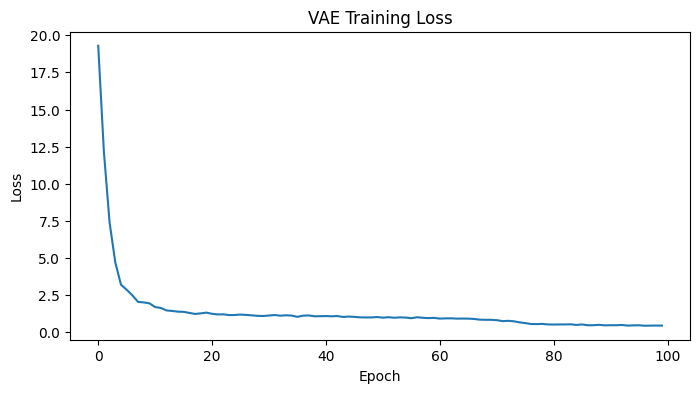

In [5]:
# =============================================================================
# 5. VAE dengan Subclassing dan Encode/Decode
# =============================================================================
latent_dim = 4
input_dim = n_features

class VAE(Model):
    def __init__(self, latent_dim, input_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.input_dim = input_dim

        # Encoder layers
        self.enc_dense1 = layers.Dense(64, activation='relu')
        self.enc_dense2 = layers.Dense(32, activation='relu')
        self.z_mean_layer = layers.Dense(latent_dim)
        self.z_log_var_layer = layers.Dense(latent_dim)

        # Decoder layers
        self.dec_dense1 = layers.Dense(32, activation='relu')
        self.dec_dense2 = layers.Dense(64, activation='relu')
        self.dec_output = layers.Dense(input_dim, activation='linear')

    def sampling(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def encode(self, inputs):
        h = self.enc_dense1(inputs)
        h = self.enc_dense2(h)
        z_mean = self.z_mean_layer(h)
        z_log_var = self.z_log_var_layer(h)
        return z_mean, z_log_var

    def decode(self, z):
        d = self.dec_dense1(z)
        d = self.dec_dense2(d)
        return self.dec_output(d)

    def call(self, inputs):
        z_mean, z_log_var = self.encode(inputs)
        z = self.sampling([z_mean, z_log_var])
        reconstructed = self.decode(z)

        # Losses
        reconstruction_loss = tf.reduce_mean(tf.square(inputs - reconstructed)) * self.input_dim
        kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        self.add_loss(reconstruction_loss + kl_loss)

        return reconstructed

# Instantiate dan compile VAE
vae = VAE(latent_dim, input_dim)
vae.compile(optimizer='adam')

# Pastikan data failure ada
if len(X_failure_train) == 0:
    raise ValueError("Tidak ada data failure! Tambahkan data dummy atau periksa kembali.")

print("Melatih VAE pada data failure...")
history = vae.fit(X_failure_train,
                  epochs=100,
                  batch_size=16,
                  verbose=1,
                  shuffle=True)

# Plot loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.title('VAE Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [6]:
# =============================================================================
# 6. Generate Data Failure Sintetis
# =============================================================================
n_synthetic = 200

# Ambil sample dari distribusi normal standar di ruang laten
random_latent = np.random.normal(size=(n_synthetic, latent_dim))

# Decode untuk mendapatkan fitur sintetis
synthetic_features = vae.decode(random_latent).numpy()  # konversi ke numpy

# Beri label RUL kecil (0-10)
synthetic_rul = np.random.uniform(0, 10, n_synthetic)

# Gabungkan dengan data failure asli
X_failure_combined = np.vstack([X_failure_train, synthetic_features])
y_failure_combined = np.concatenate([y_failure_train, synthetic_rul])

print(f"Total data failure setelah augmentasi: {len(X_failure_combined)}")

Total data failure setelah augmentasi: 372


In [7]:
# =============================================================================
# 7. Gabungkan Data Training: Normal (semua data training) + Failure (asli+sintetis)
# =============================================================================
# Ambil data normal dari training (RUL >= 10)
normal_idx_train = np.where(y_train >= 10)[0]
X_normal_train = X_train_scaled[normal_idx_train]
y_normal_train = y_train[normal_idx_train]

# Gabungkan normal + failure (asli+sintetis)
X_train_aug = np.vstack([X_normal_train, X_failure_combined])
y_train_aug = np.concatenate([y_normal_train, y_failure_combined])

print(f"Ukuran data training setelah augmentasi: {X_train_aug.shape}")

Ukuran data training setelah augmentasi: (1800, 10)



📊 Evaluasi Random Forest pada Test Set:
MAE  : 0.468
RMSE : 0.590
R²   : 1.000


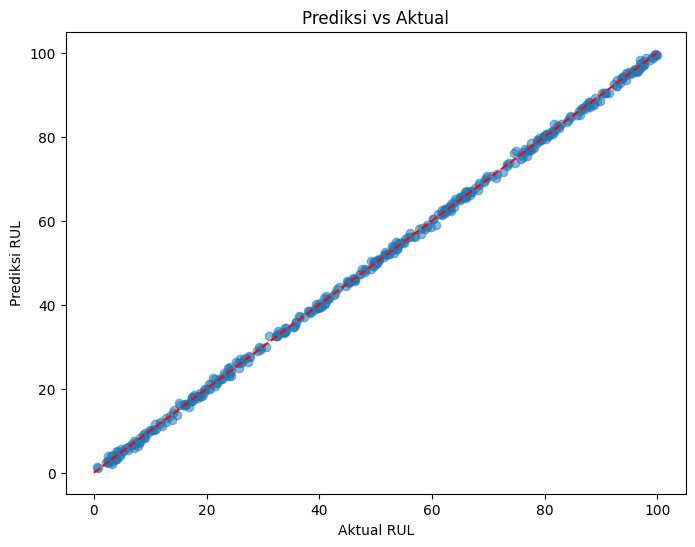

In [8]:
# =============================================================================
# 8. Latih Random Forest untuk Prediksi RUL
# =============================================================================
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_aug, y_train_aug)

# =============================================================================
# 9. Evaluasi pada Test Set
# =============================================================================
y_pred = rf.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Evaluasi Random Forest pada Test Set:")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

# Plot prediksi vs aktual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, 100], [0, 100], 'r--')
plt.xlabel('Aktual RUL')
plt.ylabel('Prediksi RUL')
plt.title('Prediksi vs Aktual')
plt.show()

In [9]:
# =============================================================================
# 10. Testing: Prediksi Waktu Kerusakan untuk Sampel Baru
# =============================================================================
# Ambil satu sampel dari test set sebagai contoh
sample_idx = 0
sample_features = X_test_scaled[sample_idx:sample_idx+1]
actual_rul = y_test[sample_idx]
predicted_rul = rf.predict(sample_features)[0]

print("\n🔧 Contoh Prediksi untuk Satu Mesin:")
print(f"Fitur mesin (terstandarisasi): {sample_features[0][:5]}...")
print(f"RUL aktual  : {actual_rul:.2f}")
print(f"RUL prediksi: {predicted_rul:.2f}")

if predicted_rul < 10:
    print("⚠️ Mesin diprediksi akan rusak dalam waktu dekat (RUL < 10)!")
else:
    print("✅ Mesin masih dalam kondisi baik.")

# =============================================================================
# 11. Simulasi Prediksi untuk Data Baru (Tanpa Label)
# =============================================================================
# Misal kita memiliki data sensor baru dari mesin yang sedang beroperasi
new_sensor_data = np.random.normal(0, 1, (1, n_features))  # contoh
new_scaled = scaler.transform(new_sensor_data)
new_pred = rf.predict(new_scaled)[0]
print(f"\n🆕 Data sensor baru -> Prediksi RUL: {new_pred:.2f}")
if new_pred < 10:
    print("⚠️ Mesin perlu perawatan segera!")
else:
    print("✅ Mesin aman.")


🔧 Contoh Prediksi untuk Satu Mesin:
Fitur mesin (terstandarisasi): [-0.97083768 -1.02297383  0.97945497 -0.93538842 -0.91936508]...
RUL aktual  : 77.64
RUL prediksi: 78.53
✅ Mesin masih dalam kondisi baik.

🆕 Data sensor baru -> Prediksi RUL: 1.93
⚠️ Mesin perlu perawatan segera!
